# Project Problem Statement: Helping IPL Mumbai Indians Win with Data

---

### The Background (Context)
In T20 cricket, games are won or lost by very tiny margins. One bad decision - like which players should a team buy in auction, choosing to bat when you should have bowled, or not knowing how many runs are "enough" on a tricky pitch - can lose a team the match. 

### The Problem
IPL teams (like the Mumbai Indians) have tons of match data, but it is stuck in raw spreadsheets. Coaches and captains cannot easily use it. They often have to rely on their "gut feeling" to make big decisions during a match or when planning their strategy. They need a data analyst to turn this raw data into clear, simple answers.

### My Goal (What I Did in This Project)
As the Data Analyst, my job was to analyze the historical IPL data and break it down into 8 simple conclusions to help the team plan better. I divided my work into three areas:

**1. Understanding the Competition**

Win Count for each Team: Figured out which teams have historically been the most dominant.

Who Won by Highest Margin: Checked which matches were massive blowouts to see what a "perfect game" looks like.

**2. Mastering Match-Day Decisions**

Effect of Toss on Match & Impact of Toss Result on Win: Checked if winning the toss actually helps a team win the match, and whether choosing to bat or bowl first changes the outcome.

Average Score Range: Found the safe score range a team needs to hit to feel safe about winning.

**3. Optimizing Players and Stadiums (The Mumbai Indians Focus)**

Best Players in IPL: Identified the top match-winners across tournament history.

Impact of Bowler & Batsman in Victory: Figured out who plays a bigger role in winning games—is it the explosive batsmen or the wicket-taking bowlers?

In which Stadium Mumbai Indians played best: Found MI's favorite hunting grounds so the team can maximize their home-field advantage.

---

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("IPL.csv")
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [3]:
for col in df.columns:
    print(col)

match_id
date
venue
team1
team2
stage
toss_winner
toss_decision
first_ings_score
first_ings_wkts
second_ings_score
second_ings_wkts
match_winner
won_by
margin
player_of_the_match
top_scorer
highscore
best_bowling
best_bowling_figure


In [4]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [5]:
df[df.duplicated()]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure


#### <u> CONCLUSION:

Data is clean, and is can be used for analysis!

---

## 1. Win Count for each Team

In [6]:
df_max = df["match_winner"].value_counts()

In [7]:
df_max = df_max.reset_index()
df_max

,match_winner,count
0,Gujarat,12
1,Rajasthan,10
2,Banglore,9
3,Lucknow,9
4,Delhi,7
5,Punjab,7
6,Kolkata,6
7,Hyderabad,6
8,Chennai,4
9,Mumbai,4


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import plotly.express as px

In [10]:
fig = px.bar(df_max, x="match_winner", y="count")

In [11]:
fig.update_layout(xaxis_title = "match winner", yaxis_title = "win count")
fig

---

## 2. Effect of Toss on Match

<Axes: xlabel='toss_decision', ylabel='count'>

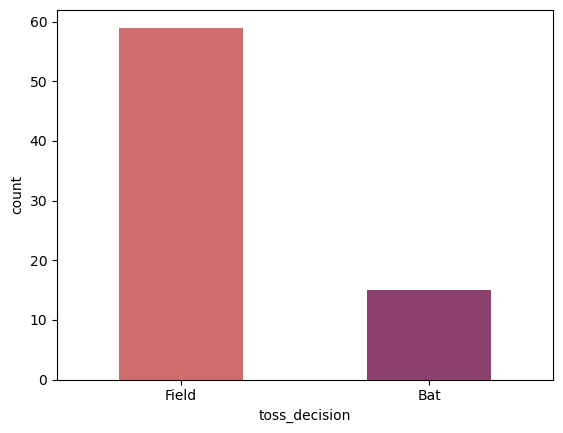

In [12]:
sns.countplot(df, x=df["toss_decision"], width = 0.5, palette = "flare", hue = "toss_decision")

In [13]:
df_2win = df.query("toss_winner == match_winner").reset_index(drop = True)

In [14]:
df_2win_shape = df_2win.shape

In [15]:
df_2win_shape = df_2win_shape[0]
df_2win_shape

36

In [16]:
df_0win = df.query("toss_winner != match_winner").reset_index()

In [17]:
df_0win_shape = df_0win.shape

In [18]:
df_0win_shape = df_0win_shape[0]
df_0win_shape

38

Text(0, 0.5, 'Number of Match Wins')

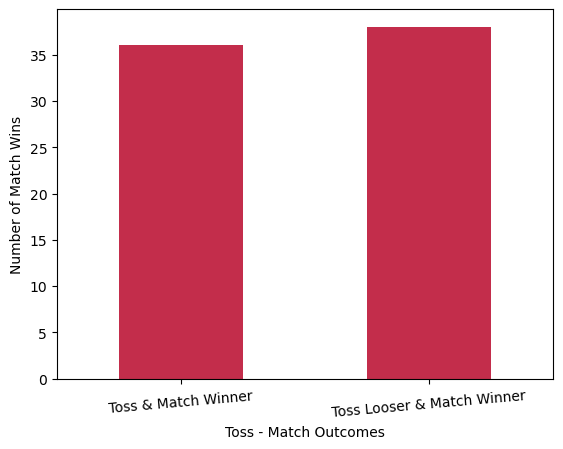

In [19]:
sns.barplot(x = ["Toss & Match Winner", "Toss Looser & Match Winner"], y = [df_2win_shape, df_0win_shape], width = 0.5, color = "crimson")
plt.xticks(rotation = 5)
plt.xlabel("Toss - Match Outcomes")
plt.ylabel("Number of Match Wins")

#### <U>CONCLUSION:

No strong conclusive retationship found between toss win & match win!

During match maximum choose, to do fielding first.

---

## 3. Impact of Toss Result on Win

In [20]:
df["toss_decision"].unique()

array(['Field', 'Bat'], dtype=object)

In [21]:
df_bat = df.query("toss_decision = Bat" and "toss_winner == match_winner")

In [22]:
df_bat_win = df_bat.shape
df_bat_win = df_bat_win[0]
df_bat_win

36

In [23]:
df_field = df.query("toss_decision = Field" and "toss_winner == match_winner")

In [24]:
df_field_win = df_field.shape
df_field_win = df_field_win[0]
df_field_win

36

Text(0, 0.5, 'Number of Match Wins')

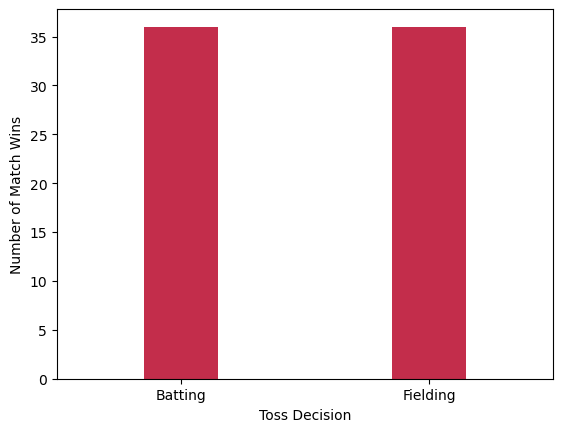

In [25]:
sns.barplot(x = ["Batting", "Fielding"], y = [df_bat_win, df_field_win], color = "crimson", width = 0.3)
plt.xlabel("Toss Decision")
plt.ylabel("Number of Match Wins")

#### <U>CONCLUSION:

No impact of choosing Fielding & Batting First.

---

## 4. Best Players in IPL

In [26]:
df_player = df["player_of_the_match"].value_counts().reset_index()

In [27]:
df_player = df_player.query("count >= 2")
df_player = df_player.rename(columns={"player_of_the_match":"player"})
df_player.head()

,player,count
0,Kuldeep Yadav,4
1,Jos Buttler,3
2,Umesh Yadav,2
3,Quinton de Kock,2
4,David Miller,2


In [28]:
df_scorer = df["top_scorer"].value_counts().reset_index()
df_scorer = df_scorer.query("count >=2")
df_scorer = df_scorer.rename( columns = {"top_scorer":"player"})
df_scorer.head()

,player,count
0,Jos Buttler,7
1,Quinton de Kock,5
2,Liam Livingstone,4
3,Shubman Gill,4
4,KL Rahul,4


In [29]:
df_bowler = df["best_bowling"].value_counts().reset_index()
df_bowler = df_bowler.query("count >=2")
df_bowler = df_bowler.rename( columns = {"best_bowling":"player"})
df_bowler.head()

,player,count
0,Yuzvendra Chahal,5
1,Rashid Khan,4
2,T Natarajan,3
3,Kagiso Rabada,3
4,Jasprit Bumrah,3


In [30]:
df_player_scorer = pd.merge(df_player, df_scorer, how = "inner", on = "player").reset_index(drop = True)

In [31]:
df_player_scorer = df_player_scorer.rename(columns = {"count_x":"player_of_the_match", "count_y":"top_scorer"})
df_player_scorer.sort_values("top_scorer", ascending = False).reset_index(drop = True)

,player,player_of_the_match,top_scorer
0,Jos Buttler,3,7
1,Quinton de Kock,2,5
2,Shubman Gill,2,4
3,Rahul Tripathi,2,2
4,Hardik Pandya,2,2


([<matplotlib.axis.XTick at 0x1a4e0a33110>,
 [Text(0, 0, 'Jos Buttler'),
  Text(1, 0, 'Quinton de Kock'),
  Text(2, 0, 'Rahul Tripathi'),
  Text(3, 0, 'Hardik Pandya'),
  Text(4, 0, 'Shubman Gill')])

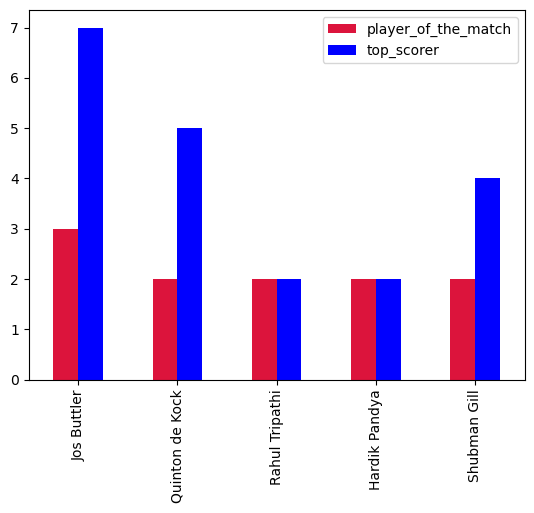

In [32]:
df_player_scorer.plot(kind = "bar", color = ["crimson", "blue"])
plt.xticks([0,1,2,3,4], df_player_scorer["player"])

#### <U>CONCLUSION:

Best Top 3 Batsman in IPL are **Jos Buttler** followed by **Quinton de Kock** and **Shubman Gill** respectively.

Having these players in team can ensure victory in matches.

In [33]:
df_player_bowling = pd.merge(df_player, df_bowler, how = "inner", on = "player").reset_index(drop = True)

In [34]:
df_player_bowling = df_player_bowling.rename(columns = {"count_x":"player_of_the_match", "count_y":"best_bowling"})
df_player_bowling.sort_values("best_bowling", ascending = False).reset_index(drop = True)

,player,player_of_the_match,best_bowling
0,Yuzvendra Chahal,2,5
1,Kuldeep Yadav,4,3
2,Jasprit Bumrah,2,3
3,Avesh Khan,2,3
4,Umran Malik,2,2
5,Hardik Pandya,2,2
6,Wanindu Hasaranga,2,2


([<matplotlib.axis.XTick at 0x1a4e0b17110>,
 [Text(0, 0, 'Kuldeep Yadav'),
  Text(1, 0, 'Umran Malik'),
  Text(2, 0, 'Hardik Pandya'),
  Text(3, 0, 'Jasprit Bumrah'),
  Text(4, 0, 'Yuzvendra Chahal'),
  Text(5, 0, 'Wanindu Hasaranga'),
  Text(6, 0, 'Avesh Khan')])

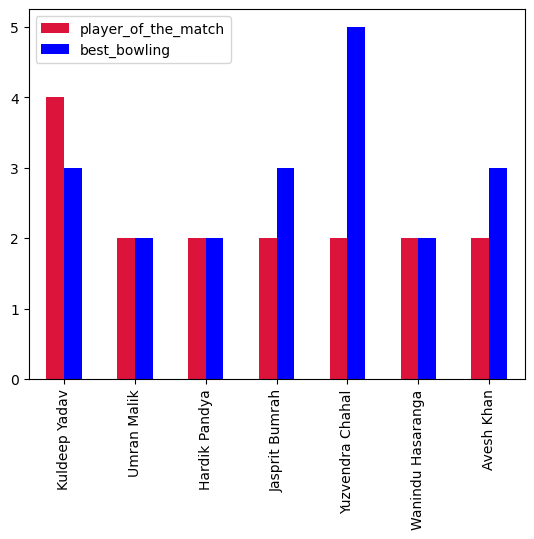

In [35]:
df_player_bowling.plot(kind = "bar", color = ["crimson", "blue"])
plt.xticks([0,1,2,3,4,5,6], df_player_bowling["player"])

#### <U>CONCLUSION:

Best Top 3 Bowlers in IPL are **Yuzvendra Chahal** but with less player of the match score, followed by **Kuldeep Yadav** with higher player of the match count than Yuzvendra, followed by **Avesh Khan**.

Having these players in team can ensure victory in matches.

---

## 5. Impact of Bowler & Batsman in Victory

In [36]:
df["won_by"].unique()

array(['Wickets', 'Runs'], dtype=object)

In [37]:
df_won_by = df["won_by"].value_counts().reset_index()
df_won_by

,won_by,count
0,Wickets,37
1,Runs,37


([<matplotlib.axis.XTick at 0x1a4e0baf750>,
 [Text(0, 0, 'Wickets'), Text(1, 0, 'Runs')])

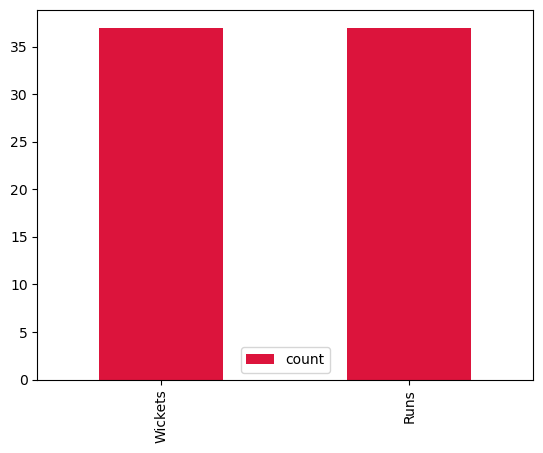

In [38]:
df_won_by.plot(kind = "bar", color = "crimson")
plt.xticks([0,1], df_won_by["won_by"])

#### <u> CONCLUSION:

Equal impact of bowlers & batsman on a match.

---

## 6. In which Stadium Mumbai Indians played best

In [39]:
df["venue"].value_counts().reset_index()

,venue,count
0,"Wankhede Stadium, Mumbai",21
1,"Dr DY Patil Sports Academy, Mumbai",20
2,"Brabourne Stadium, Mumbai",16
3,"Maharashtra Cricket Association Stadium,Pune",13
4,"Eden Gardens, Kolkata",2
5,"Narendra Modi Stadium, Ahmedabad",2


In [40]:
df_stadium = df.query('venue in ["Wankhede Stadium, Mumbai", "Dr DY Patil Sports Academy, Mumbai", "Brabourne Stadium, Mumbai", "Maharashtra Cricket Association Stadium,Pune", "Eden Gardens, Kolkata", "Narendra Modi Stadium, Ahmedabad"] and match_winner == "Mumbai"').reset_index(drop=True)
df_stadium

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,44,"April 30,2022","Dr DY Patil Sports Academy, Mumbai",Mumbai,Rajasthan,Group,Mumbai,Field,158,6,161,5,Mumbai,Wickets,5,Suruakumar Yadav,Jos Buttler,67,Rilley Meredith,2--24
1,51,"May 6,2022","Brabourne Stadium, Mumbai",Gujarat,Mumbai,Group,Gujarat,Field,177,6,172,5,Mumbai,Runs,5,Tim David,W. Saha,55,Rashid Khan,2--24
2,59,"May 12,2022","Wankhede Stadium, Mumbai",Chennai,Mumbai,Group,Mumbai,Field,97,10,103,5,Mumbai,Wickets,5,Daniel Sams,MS Dhoni,36,Daniel Sams,3--16
3,69,"May 21,2022","Wankhede Stadium, Mumbai",Delhi,Mumbai,Group,Mumbai,Field,159,7,160,5,Mumbai,Wickets,5,Jasprit Bumrah,Ishan Kishan,48,Jasprit Bumrah,3--25


In [41]:
df_mumbai_venue = df_stadium["venue"].value_counts().reset_index()
df_mumbai_venue

,venue,count
0,"Wankhede Stadium, Mumbai",2
1,"Dr DY Patil Sports Academy, Mumbai",1
2,"Brabourne Stadium, Mumbai",1


([<matplotlib.axis.XTick at 0x1a4e0c379d0>,
 [Text(0, 0, 'Wankhede Stadium, Mumbai'),
  Text(1, 0, 'Dr DY Patil Sports Academy, Mumbai'),
  Text(2, 0, 'Brabourne Stadium, Mumbai'),
  Text(3, 0, 'Maharashtra Cricket Association Stadium,Pune'),
  Text(4, 0, 'Eden Gardens, Kolkata'),
  Text(5, 0, 'Narendra Modi Stadium, Ahmedabad')])

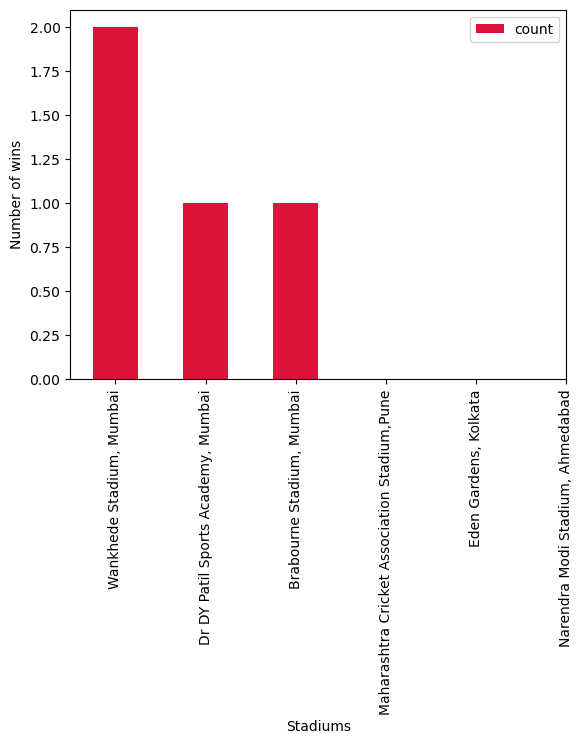

In [42]:
df_mumbai_venue.plot(kind="bar", color = "crimson")
plt.xlabel("Stadiums")
plt.ylabel("Number of wins")
plt.xticks([0,1,2,3,4,5],["Wankhede Stadium, Mumbai", "Dr DY Patil Sports Academy, Mumbai", "Brabourne Stadium, Mumbai", "Maharashtra Cricket Association Stadium,Pune", "Eden Gardens, Kolkata", "Narendra Modi Stadium, Ahmedabad"])

#### <U> CONCLUSION:

Mumbai Indians won in stadiums that are in mumbai only.

---

## 7. Average Score Range required to ensure Probability of a Victory

In [43]:
import numpy as np

In [44]:
fig = px.box(
    df, 
    y=["first_ings_score", "second_ings_score"],
    labels={"value": "Scores", "variable": "Innings"}
)

fig.show()

#### <u> CONCLUSION:

The Average Maximum Score of both Innings:

In [45]:
avg_max = (222+211)/2
avg_max

216.5

The Average Third Qurtile Score of both Innings:

In [46]:
avg_q3 = (193+176)/2
avg_q3

184.5

The Average Median Score of both Innings:

In [47]:
avg_median = (169.5+160)/2
avg_median

164.75

---

## 8. Who Won by Highest Margin

In [48]:
df_margin = df [df ['won_by'] == 'Runs'].sort_values (by = 'margin', ascending=False).head(10).reset_index(drop = True)
df_margin

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,55,"May 8,2022","Dr DY Patil Sports Academy, Mumbai",Chennai,Delhi,Group,Delhi,Field,208,6,117,10,Chennai,Runs,91,Devon Conway,Devon Conway,87,Moeen Ali,3--13
1,53,"May 7,2022","Maharashtra Cricket Association Stadium,Pune",Kolkata,Lucknow,Group,Kolkata,Field,176,7,101,10,Lucknow,Runs,75,Avesh Khan,Quinton de Kock,50,Avesh Khan,3--19
2,54,"May 8,2022","Wankhede Stadium, Mumbai",Banglore,Hyderabad,Group,Banglore,Bat,192,3,125,10,Banglore,Runs,67,Wanindu Hasaranga,Faf du Plessis,73,Wanindu Hasaranga,5--18
3,57,"May 10,2022","Maharashtra Cricket Association Stadium,Pune",Lucknow,Gujarat,Group,Gujarat,Bat,144,4,82,10,Gujarat,Runs,62,Shubman Gill,Shubman Gill,63,Rashid Khan,4--24
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
5,61,"May 14,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Kolkata,Group,Kolkata,Bat,177,6,123,8,Kolkata,Runs,54,Andre Russell,Andre Russell,49,Andre Russell,3--22
6,11,"April 3,2022","Brabourne Stadium, Mumbai",Chennai,Punjab,Group,Chennai,Field,180,8,126,10,Punjab,Runs,54,Liam Livingstone,Liam Livingstone,60,Rahul Chahar,3--25
7,60,"May 13,2022","Brabourne Stadium, Mumbai",Banglore,Punjab,Group,Banglore,Field,209,9,155,9,Punjab,Runs,54,Jonny Bairstow,Liam Livingstone,70,Harshal Patel,4--34
8,56,"May 9,2022","Dr DY Patil Sports Academy, Mumbai",Kolkata,Mumbai,Group,Mumbai,Field,165,9,113,10,Kolkata,Runs,52,Jasprit Bumrah,Ishan Kishan,51,Jasprit Bumrah,5--10
9,19,"April 10,2022","Brabourne Stadium, Mumbai",Delhi,Kolkata,Group,Kolkata,Field,215,5,171,10,Delhi,Runs,44,Kuldeep Yadav,David Warner,61,Kuldeep Yadav,4--35


In [49]:
df_margin["match_winner"].value_counts()

match_winner
Kolkata      2
Punjab       2
Chennai      1
Lucknow      1
Banglore     1
Gujarat      1
Rajasthan    1
Delhi        1
Name: count, dtype: int64

#### <u> CONCLUSION:

Chennai won by highest margin, i.e. of 91 runs.

But, Kolkata & Punjab are in top 10 who scored by highest margin.